# Bitcoin Blockchain Analytics

Reads summary CSVs produced by the Rust `analytics` binary and plots them.
All x-axes use dates parsed from block timestamps.

In [46]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import matplotlib.dates as mdates
import numpy as np

BASE = "F:/csv/analytics/"
FIGSIZE = (14, 5)
plt.rcParams['figure.dpi'] = 100

def load(name):
    df = pd.read_csv(f"{BASE}{name}")
    if 'DATE_TIME' in df.columns:
        df['DATE'] = pd.to_datetime(df['DATE_TIME'])
    return df

---
## A. Network Analytics

### A1. Block Interval Distribution

Bitcoin targets one block every 10 minutes, but actual intervals vary due to hashrate fluctuations and luck. This histogram shows the distribution of time gaps between consecutive blocks. The red dashed line marks the 600-second (10 min) target. A peak near 600s with a long right tail is expected — blocks occasionally take over an hour when miners get unlucky.

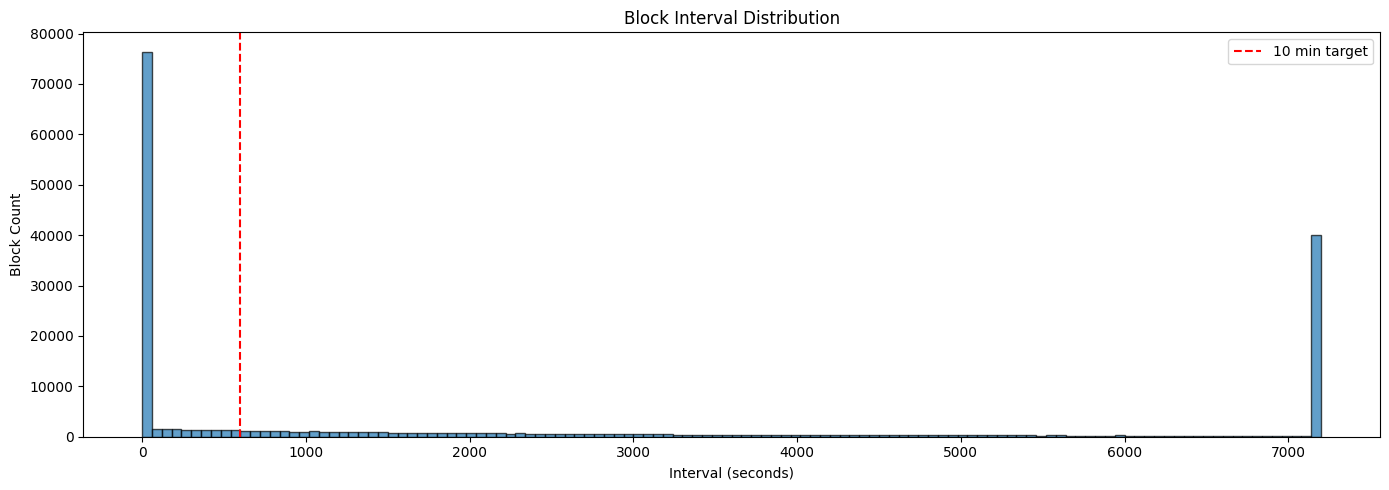

In [47]:
df = load('interval.csv')

fig, ax = plt.subplots(figsize=FIGSIZE)
ax.hist(df['INTERVAL_SECONDS'].clip(0, 7200), bins=120, edgecolor='black', alpha=0.7)
ax.axvline(x=600, color='red', linestyle='--', label='10 min target')
ax.set_xlabel('Interval (seconds)')
ax.set_ylabel('Block Count')
ax.set_title('Block Interval Distribution')
ax.legend()
plt.tight_layout()
plt.show()

### A1b. Rolling Block Interval Over Time

A 144-block rolling average of block intervals (144 blocks ~ 1 day). When the line is above 600s, blocks are being found slower than target — typically before a downward difficulty adjustment. Below 600s means hashrate has increased since the last adjustment. The difficulty algorithm retargets every 2016 blocks to bring this average back to 600s.

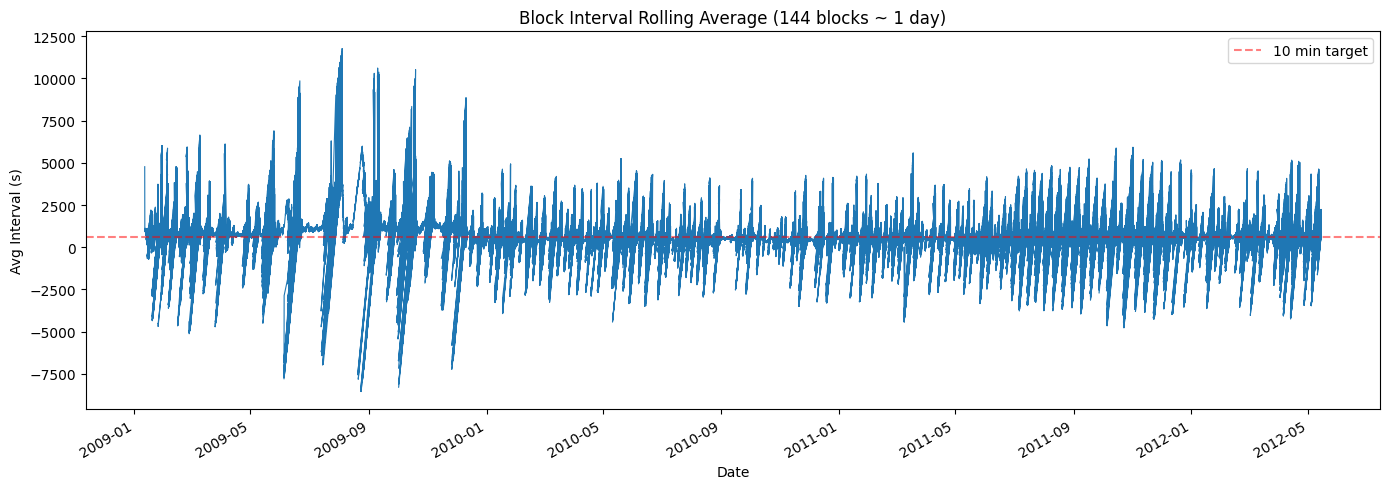

In [48]:
fig, ax = plt.subplots(figsize=FIGSIZE)
ax.plot(df['DATE'], df['INTERVAL_SECONDS'].rolling(144).mean(), linewidth=0.8)
ax.axhline(y=600, color='red', linestyle='--', alpha=0.5, label='10 min target')
ax.set_xlabel('Date')
ax.set_ylabel('Avg Interval (s)')
ax.set_title('Block Interval Rolling Average (144 blocks ~ 1 day)')
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

### A2. Block Fullness (Dual Axis)

Dual-axis chart showing transactions per block (blue) and block size in bytes (orange), both smoothed with a 100-block rolling average. Early Bitcoin had tiny blocks with just 1-2 transactions. As adoption grew, both metrics climbed — block size eventually hitting the 1MB limit, which drove the block size debate and SegWit activation.

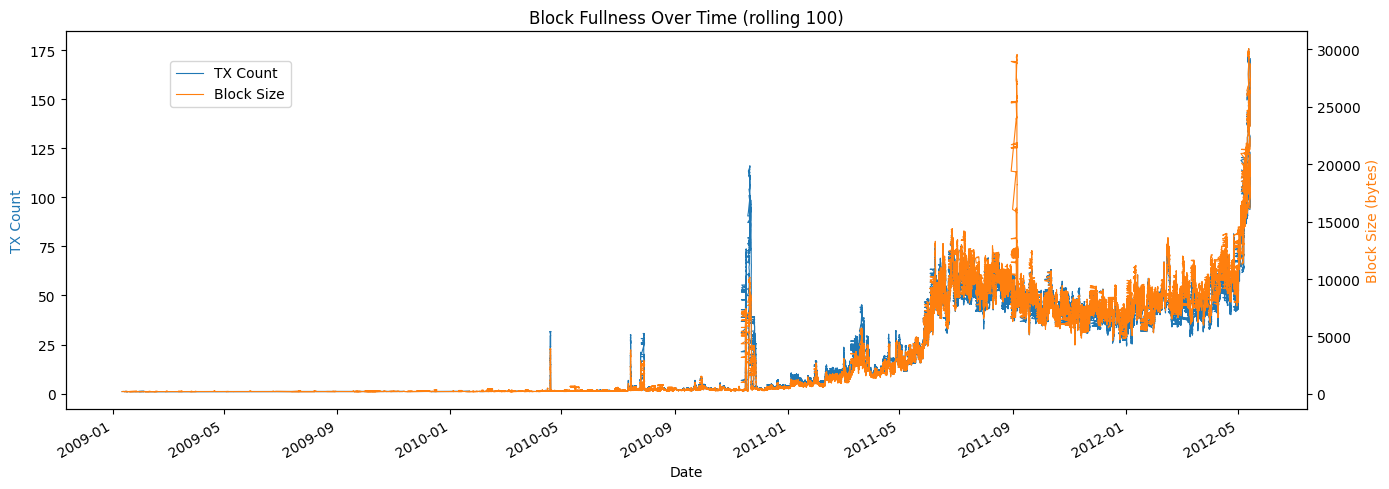

In [49]:
df = load('fullness.csv')

fig, ax1 = plt.subplots(figsize=FIGSIZE)
ax2 = ax1.twinx()
ax1.plot(df['DATE'], df['TX_COUNT'].rolling(100).mean(), color='tab:blue', linewidth=0.8, label='TX Count')
ax2.plot(df['DATE'], df['BLOCK_SIZE'].rolling(100).mean(), color='tab:orange', linewidth=0.8, label='Block Size')
ax1.set_xlabel('Date')
ax1.set_ylabel('TX Count', color='tab:blue')
ax2.set_ylabel('Block Size (bytes)', color='tab:orange')
ax1.set_title('Block Fullness Over Time (rolling 100)')
fig.legend(loc='upper left', bbox_to_anchor=(0.12, 0.88))
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

### A3. SegWit Adoption

Percentage of transactions using Segregated Witness (SegWit) per block range. SegWit activated at block 481,824 (August 2017) and adoption grew gradually as wallets upgraded. SegWit separates signature data from the transaction, enabling ~1.7x more transactions per block and fixing transaction malleability — a prerequisite for the Lightning Network.

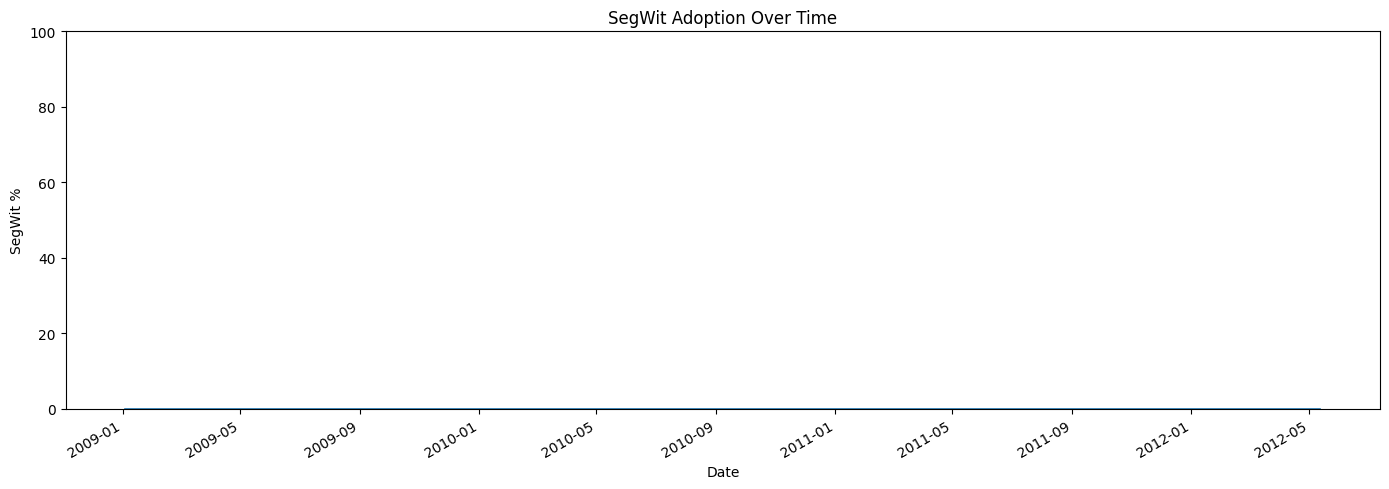

In [50]:
df = load('segwit.csv')

fig, ax = plt.subplots(figsize=FIGSIZE)
ax.plot(df['DATE'], df['SEGWIT_RATIO'] * 100, linewidth=1.2)
ax.set_xlabel('Date')
ax.set_ylabel('SegWit %')
ax.set_title('SegWit Adoption Over Time')
ax.set_ylim(0, 100)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

### A4. Fee Market (Mean vs Median)

Mean and median transaction fees (in satoshis) per block range, plotted on a log scale. The gap between mean and median reveals fee distribution skew — a few very high-fee transactions pull the mean up while most transactions pay closer to the median. Fee spikes correspond to congestion events (bull markets, inscription waves, ordinals).

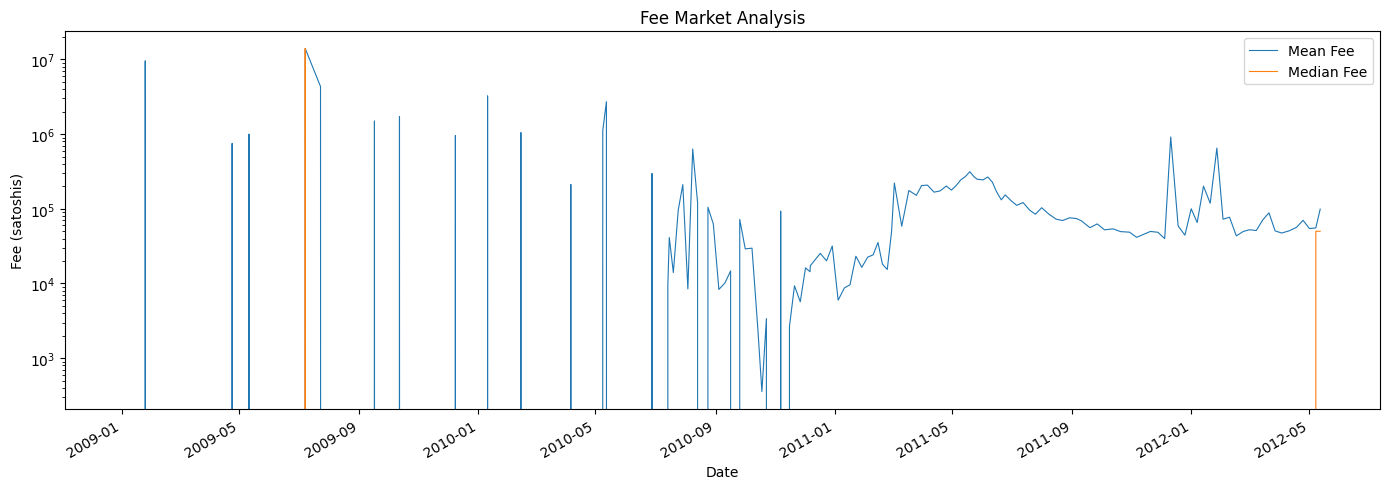

In [51]:
df = load('fee.csv')

fig, ax = plt.subplots(figsize=FIGSIZE)
ax.plot(df['DATE'], df['MEAN_FEE'], label='Mean Fee', linewidth=0.8)
ax.plot(df['DATE'], df['MEDIAN_FEE'], label='Median Fee', linewidth=0.8)
ax.set_xlabel('Date')
ax.set_ylabel('Fee (satoshis)')
ax.set_title('Fee Market Analysis')
ax.set_yscale('log')
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

### A5. Transaction Velocity

Number of transactions per block over time, smoothed with a 144-block rolling average. This is a direct measure of network throughput. The effective ceiling is constrained by block size/weight limits. Periods of sustained high velocity indicate heavy demand and typically correlate with higher fees.

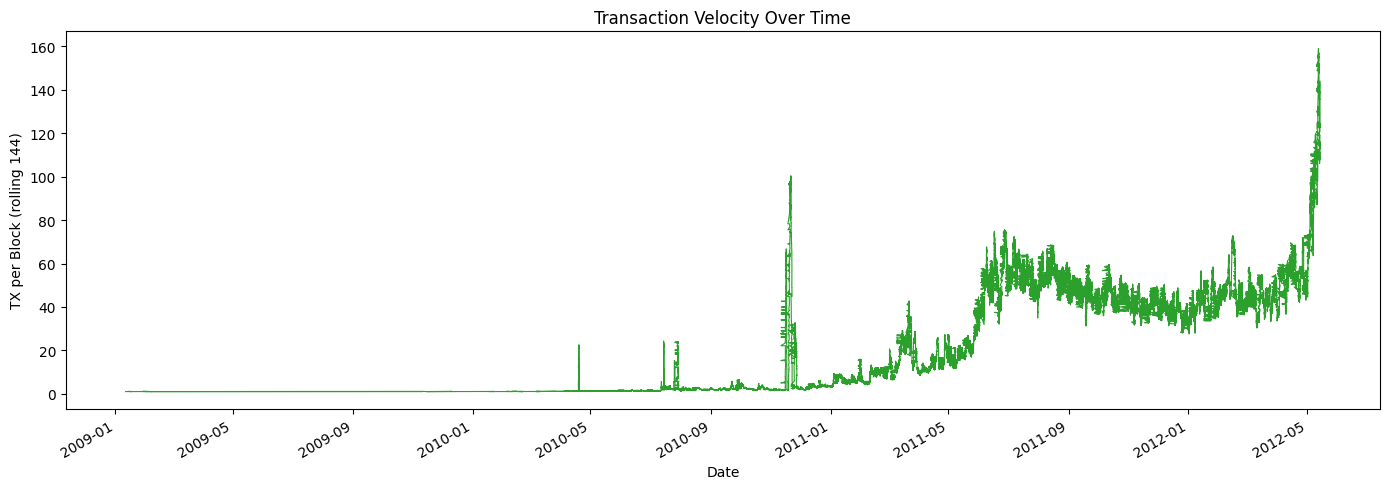

In [52]:
df = load('velocity.csv')

fig, ax = plt.subplots(figsize=FIGSIZE)
ax.plot(df['DATE'], df['TX_COUNT'].rolling(144).mean(), linewidth=0.8, color='tab:green')
ax.set_xlabel('Date')
ax.set_ylabel('TX per Block (rolling 144)')
ax.set_title('Transaction Velocity Over Time')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

---
## B. Script / Address Analytics

### B6. Script Type Evolution (Stacked Area)

Shows how Bitcoin's output script types have evolved over time as a percentage. The progression tells Bitcoin's history: early blocks used raw P2PK (public key in the script), then P2PKH (hash-based addresses starting with "1") dominated, P2SH ("3" addresses, enabling multisig) grew from 2012, and SegWit types (P2WPKH/P2WSH "bc1q", P2TR "bc1p") appeared after their respective activations.

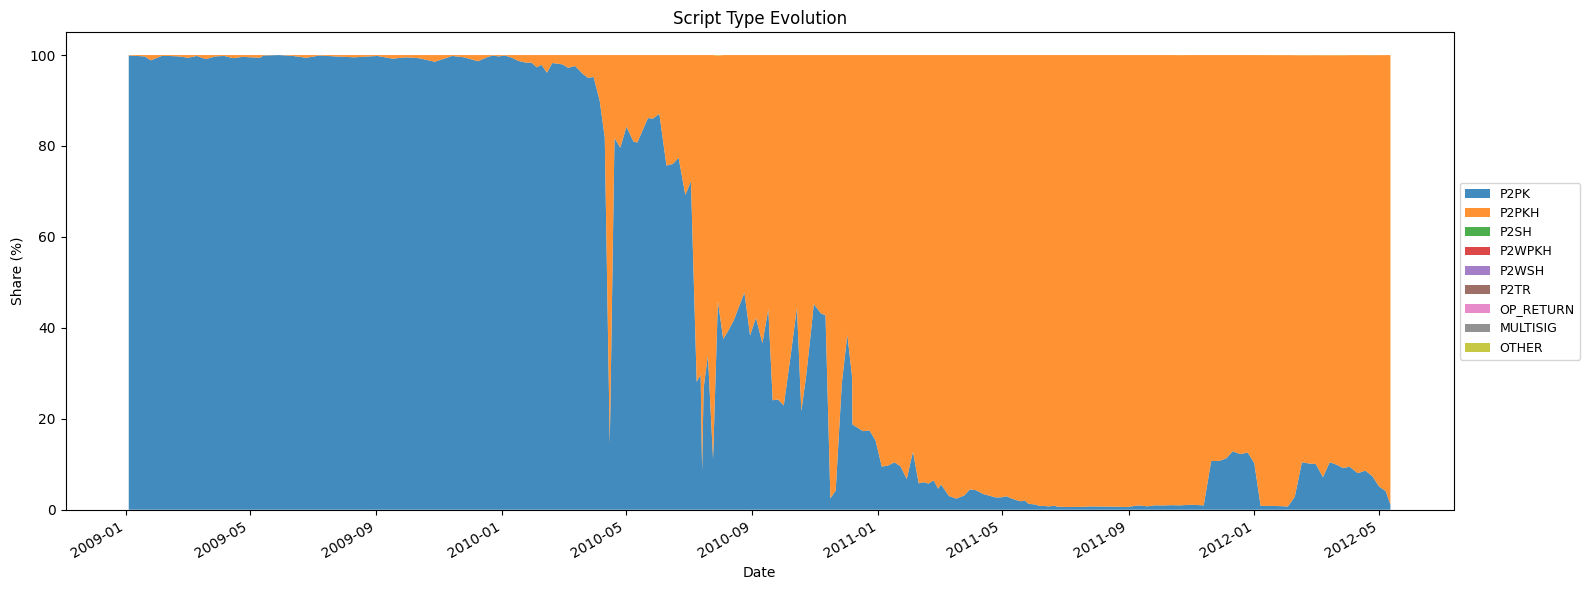

In [53]:
df = load('scripttype.csv')
cols = ['P2PK','P2PKH','P2SH','P2WPKH','P2WSH','P2TR','OP_RETURN','MULTISIG','OTHER']
totals = df[cols].sum(axis=1)
pct = df[cols].div(totals, axis=0) * 100

fig, ax = plt.subplots(figsize=(16, 6))
ax.stackplot(df['DATE'], *[pct[c] for c in cols], labels=cols, alpha=0.85)
ax.set_xlabel('Date')
ax.set_ylabel('Share (%)')
ax.set_title('Script Type Evolution')
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize=9)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

### B7. Dust Outputs (< 546 sats)

Counts transaction outputs with value below 546 satoshis — the dust limit. These outputs cost more in fees to spend than they're worth, effectively making them unspendable and bloating the UTXO set permanently. Dust spikes often correlate with spam attacks or stress tests on the network.

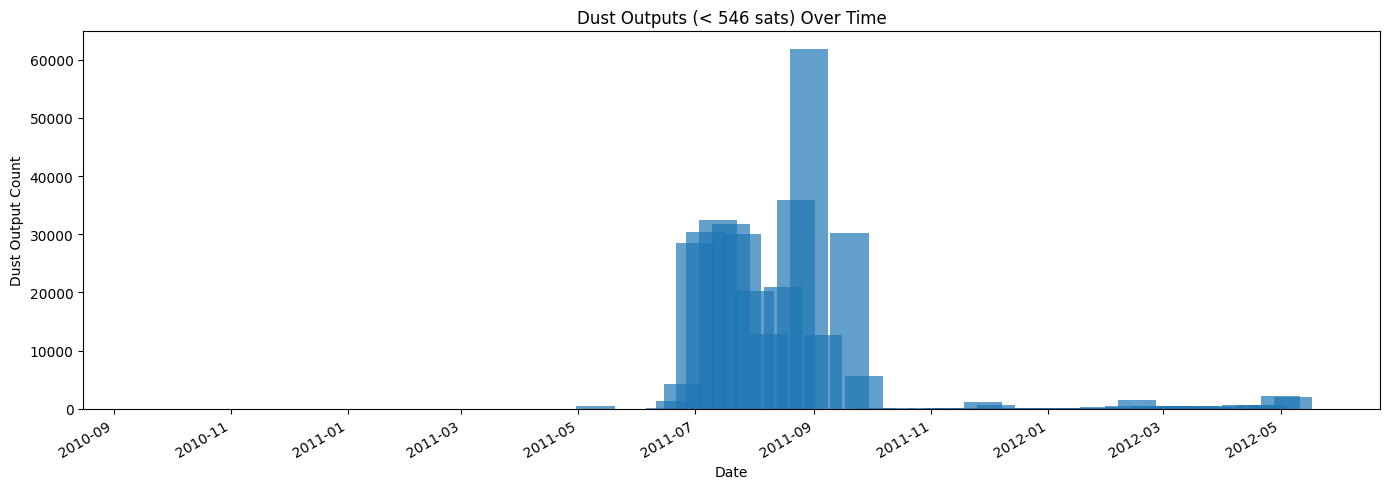

In [54]:
df = load('dust.csv')

fig, ax = plt.subplots(figsize=FIGSIZE)
ax.bar(df['DATE'], df['DUST_COUNT'], width=20, alpha=0.7)
ax.set_xlabel('Date')
ax.set_ylabel('Dust Output Count')
ax.set_title('Dust Outputs (< 546 sats) Over Time')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

---
## C. UTXO Analytics

### C8. UTXO Set Size Over Time

The total number of unspent transaction outputs (UTXOs) over time. Every full node must keep the entire UTXO set in memory for fast validation, so this metric directly impacts node resource requirements. The count grows when transactions create more outputs than they spend, and shrinks during consolidation waves.

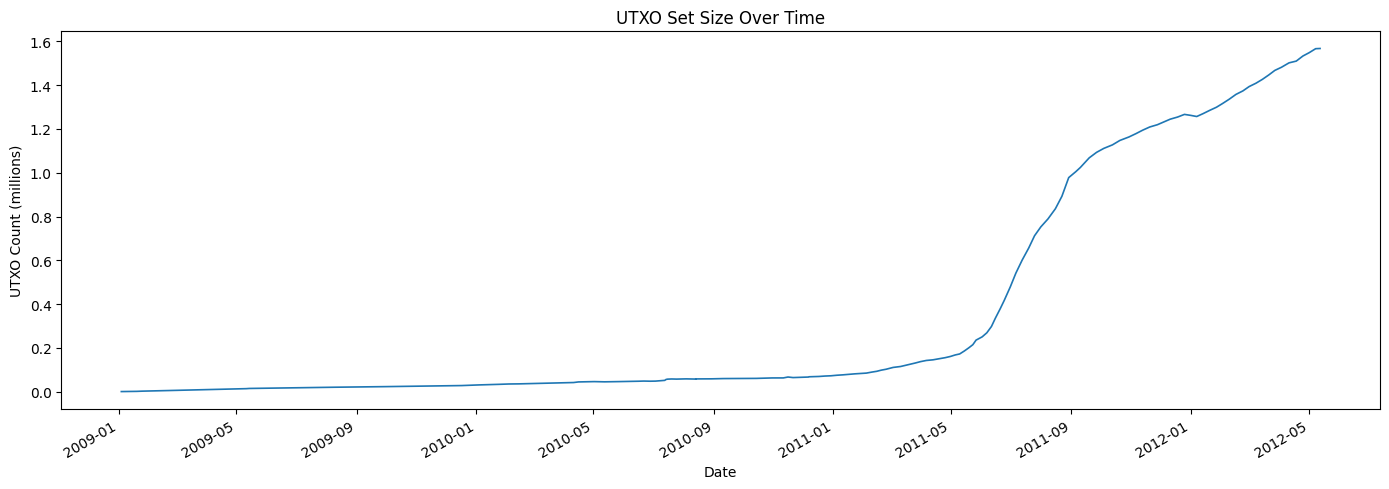

In [55]:
df = load('utxosize.csv')

fig, ax = plt.subplots(figsize=FIGSIZE)
ax.plot(df['DATE'], df['UTXO_COUNT'] / 1e6, linewidth=1.2)
ax.set_xlabel('Date')
ax.set_ylabel('UTXO Count (millions)')
ax.set_title('UTXO Set Size Over Time')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

### C9. Cumulative Coin Supply

Total BTC created over time via coinbase rewards. Bitcoin's supply schedule is deterministic: 50 BTC per block for the first 210,000 blocks, then halving every 210,000 blocks (~4 years). The curve is logarithmic, approaching the 21 million hard cap asymptotically. Over 93% of all bitcoin that will ever exist has already been mined.

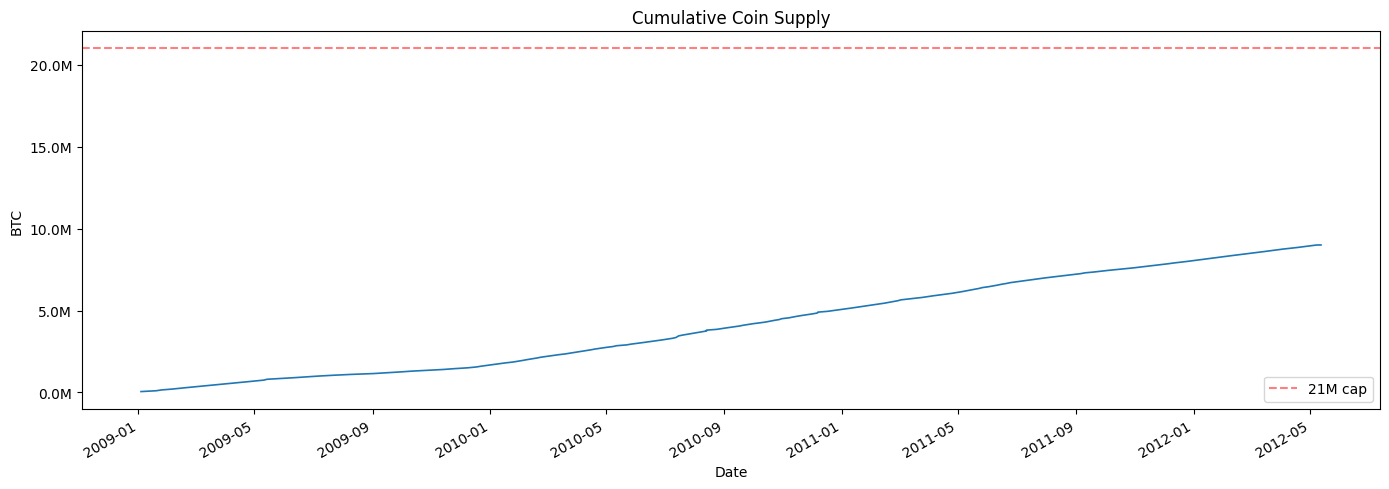

In [56]:
df = load('supply.csv')

fig, ax = plt.subplots(figsize=FIGSIZE)
ax.plot(df['DATE'], df['CUMULATIVE_BTC'], linewidth=1.2)
ax.axhline(y=21_000_000, color='red', linestyle='--', alpha=0.5, label='21M cap')
ax.set_xlabel('Date')
ax.set_ylabel('BTC')
ax.set_title('Cumulative Coin Supply')
ax.legend()
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

---
## D. Mining Analytics

### D10. Mining Difficulty (Log Scale)

Mining difficulty on a logarithmic scale. Difficulty adjusts every 2016 blocks (~2 weeks) to maintain the 10-minute block target. It encodes how hard it is to find a valid block hash below the target. The exponential growth reflects the arms race from CPUs to GPUs to FPGAs to ASICs. Plateaus or drops indicate miners going offline (e.g., China mining ban in 2021).

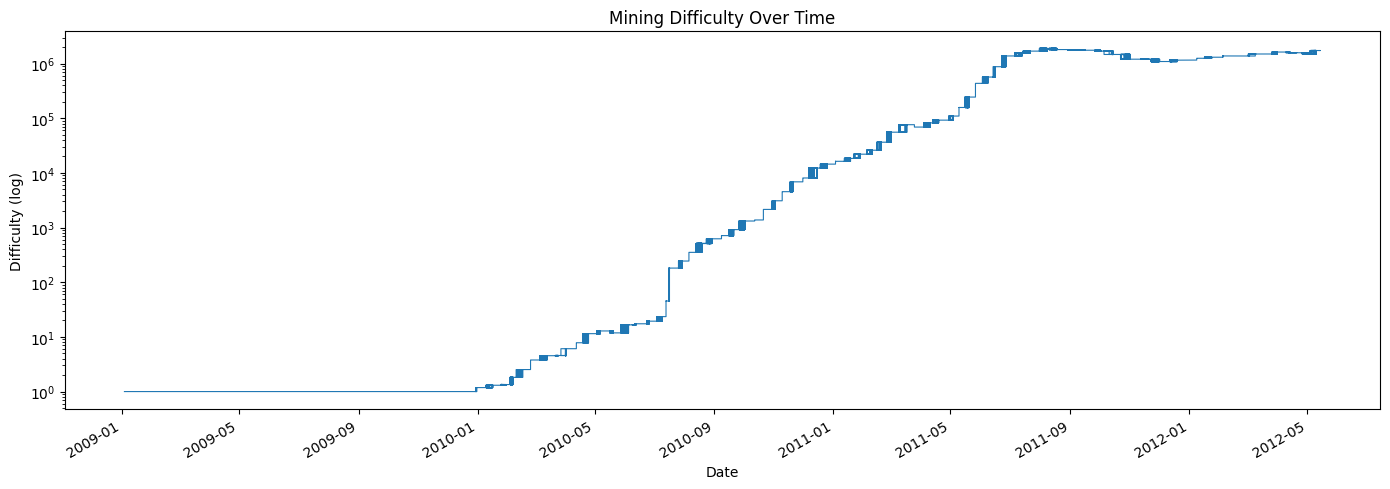

In [57]:
df = load('difficulty.csv')

fig, ax = plt.subplots(figsize=FIGSIZE)
ax.step(df['DATE'], df['DIFFICULTY'], where='post', linewidth=0.8)
ax.set_yscale('log')
ax.set_xlabel('Date')
ax.set_ylabel('Difficulty (log)')
ax.set_title('Mining Difficulty Over Time')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

### D11. Coinbase Messages

ASCII text extracted from coinbase transaction scriptSig fields. Miners can embed arbitrary data here — the most famous being Satoshi's genesis block message: "The Times 03/Jan/2009 Chancellor on brink of second bailout for banks". Mining pools use this space for pool identification tags (e.g., /Foundry USA/, /AntPool/), and miners occasionally embed personal messages or political statements.

In [58]:
df = load('coinbase.csv')
df_display = df[df['ASCII_MESSAGE'].str.len() > 10].head(50)
df_display[['DATE_TIME', 'BLOCK_HEIGHT', 'ASCII_MESSAGE']]

,DATE_TIME,BLOCK_HEIGHT,ASCII_MESSAGE
0,2009-01-03 18:15:05,0,EThe Times 03/Jan/2009 Chancellor on brink of ...
278,2011-08-04 02:15:31,139476,Eligius | test
279,2011-08-03 23:07:35,139481,Eligius | test
286,2011-08-05 12:47:00,139667,Eligius/Benedictus Deus. Benedictum Nomen Sanc...
287,2011-08-06 03:03:28,139711,"Eligius | Benedictus Iesus Christus, verus Deu..."
289,2011-08-05 08:42:59,139751,Eligius/Benedictus Deus. Benedictum Nomen Sanc...
290,2011-08-06 09:53:55,139776,Eligius | Benedictum Nomen Iesu.
291,2011-08-06 22:59:58,139833,Eligius | Benedictum Cor eius sacratissimum.
292,2011-08-07 03:33:37,139849,Eligius | Benedictus Iesus in sanctissimo alta...
293,2011-08-07 13:30:29,139906,"Eligius | Benedicta excelsa Mater Dei, Maria s..."


---
## E. OP_RETURN Analytics

### E12. OP_RETURN Usage Over Time

Count of OP_RETURN outputs per block range. OP_RETURN is Bitcoin's designated data-embedding opcode — it creates provably unspendable outputs that carry arbitrary payload data. Usage surged with protocols like Omni (Tether's original layer), Counterparty, and more recently Ordinals/BRC-20 tokens.

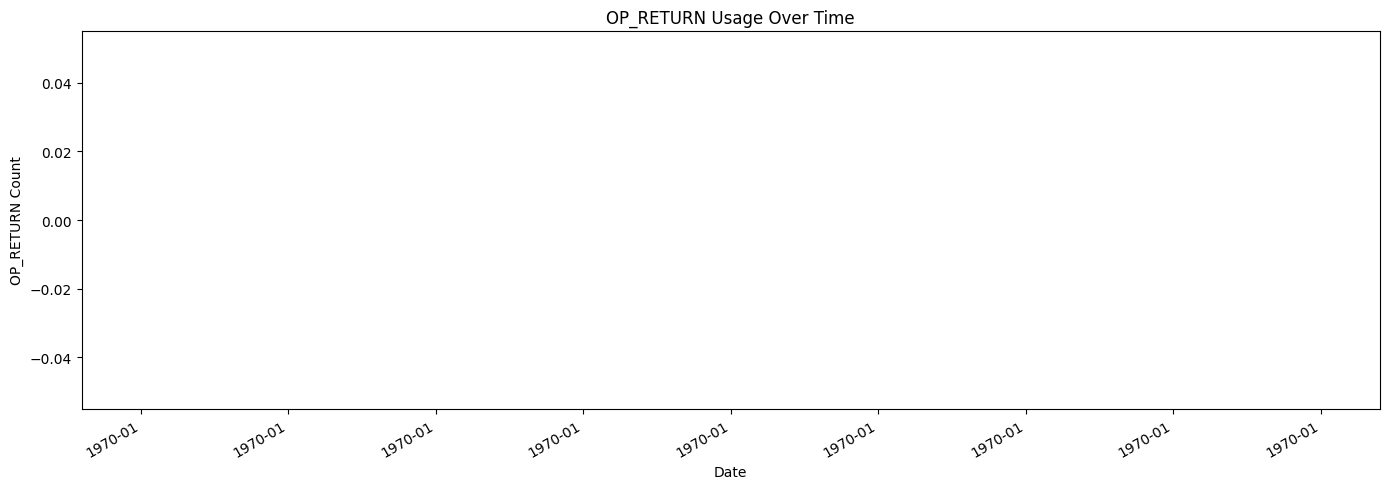

In [59]:
df = load('opreturncount.csv')

fig, ax = plt.subplots(figsize=FIGSIZE)
ax.bar(df['DATE'], df['OP_RETURN_COUNT'], width=20, alpha=0.7, color='tab:purple')
ax.set_xlabel('Date')
ax.set_ylabel('OP_RETURN Count')
ax.set_title('OP_RETURN Usage Over Time')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

### E13. Top OP_RETURN Protocol Prefixes

The most common 4-byte prefixes in OP_RETURN data, identifying which protocols embed data on Bitcoin. Each protocol uses a unique magic prefix: Omni Layer uses `omni` (0x6f6d6e69), Open Assets uses `OA` (0x4f41), Counterparty uses `SPK` (0x53504b), etc. This chart reveals which meta-protocols dominate Bitcoin's data layer.

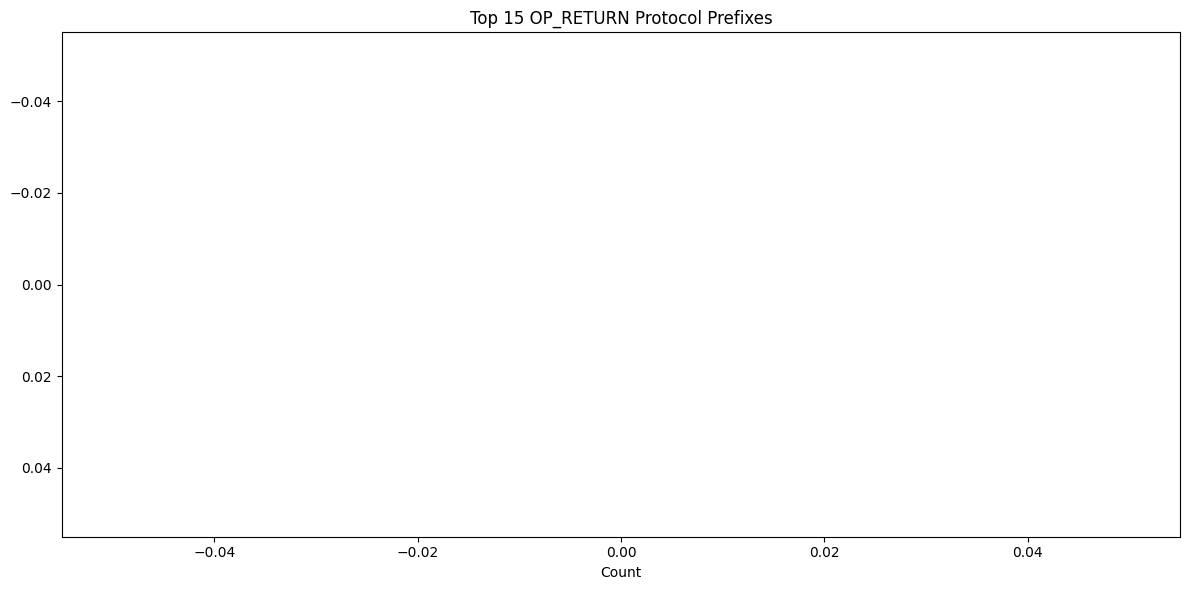

In [60]:
df = pd.read_csv(f"{BASE}opreturnprotocol.csv").head(15)

fig, ax = plt.subplots(figsize=(12, 6))
labels = [f"{row['PREFIX_ASCII']} ({row['PREFIX_HEX']})" for _, row in df.iterrows()]
ax.barh(labels, df['COUNT'], color='tab:green', alpha=0.7)
ax.set_xlabel('Count')
ax.set_title('Top 15 OP_RETURN Protocol Prefixes')
ax.invert_yaxis()
plt.tight_layout()
plt.show()